In [2]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import nilearn
from nilearn import masking
import os
import pandas as pd
import math
from sklearn.svm import SVC
import seaborn as sns
import pickle
import statsmodels
#import pingouin as pg
from scipy.stats import norm

In [ ]:
# set directories and load data
basedir = '/path/to/pain-induced-manifold-changes'
datdir = os.path.join(basedir, 'data')

file = os.path.join(datdir, 'pain-induced-manifold-changes_imgaetrial_data_for_category_classification.pickle')
with open(file, 'rb') as f:
    all_sub_dat = pickle.load(f)

sub_ids = list(all_sub_dat.keys())

In [31]:
# set conditions / ROIs
condition = [0,1,2] # 0 - warmth; 1 - low heat; 2 - high heat
rois = ['V1', 'V2', 'hV4', 'LO']

In [32]:
# run SVM

linear_SVM = SVC(kernel='linear')

all_sub_acc = pd.DataFrame({'roi':[], 'roi2num': [], 'cond':[], 'sub': [], 'mean_acc': []})

for roi2num, roi in enumerate(rois):
    for cond in condition:
        for sub in sub_ids:
            
            data = all_sub_dat[sub][roi][cond]['data']
            attr_animacy = all_sub_dat[sub][roi][cond]['attr_category']
            attr_runnum = all_sub_dat[sub][roi][cond]['attr_runnum']
  
            mean_acc = []
            runs = np.unique(all_sub_dat[sub][roi][cond]['attr_runnum'])
            for test_run in runs:
                
                # all runs other than test_run
                X_train = data[attr_runnum != test_run]
                y_train = attr_animacy[attr_runnum != test_run]
                
                # test run data only
                X_test = data[attr_runnum == test_run]
                y_test = attr_animacy[attr_runnum == test_run]
                
                # fit
                linear_SVM.fit(X_train, y_train)
                print(f'{roi} {cond} {sub} train: {linear_SVM.score(X_train, y_train)}')
                print(f'{roi} {cond} {sub} test: {linear_SVM.score(X_test, y_test)}')
                
                mean_acc.append(linear_SVM.score(X_test, y_test))
                
            mean_acc = np.mean(np.array(mean_acc)) # mean across runs
            
            tmp_df = pd.DataFrame({'roi':[roi], 'roi2num': [roi2num], 'cond':[cond], 'sub':[sub], 'mean_acc':[mean_acc]})
            all_sub_acc = pd.concat([all_sub_acc, tmp_df], ignore_index=True)
            

V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.26666666666666666
V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.0
V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.06666666666666667
V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.16666666666666666
V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.1
V1 0 pacman09 train: 1.0
V1 0 pacman09 test: 0.26666666666666666
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.16666666666666666
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.1
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.1
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.1
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.1
V1 0 pacman10 train: 1.0
V1 0 pacman10 test: 0.06666666666666667
V1 0 pacman11 train: 1.0
V1 0 pacman11 test: 0.3333333333333333
V1 0 pacman11 train: 1.0
V1 0 pacman11 test: 0.2
V1 0 pacman11 train: 1.0
V1 0 pacman11 test: 0.03333333333333333
V1 0 pacman11 train: 1.0
V1 0 pacman11 test: 0.1
V1 0 pacman11 train: 1.0
V1 0 pacman11 test: 0.1
V1 0 pacman11 train: 1.0
V1 0 pacman11 t

/tmp/ipykernel_878929/1441538530.py:8: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=all_sub_acc, x="roi", y="mean_acc",


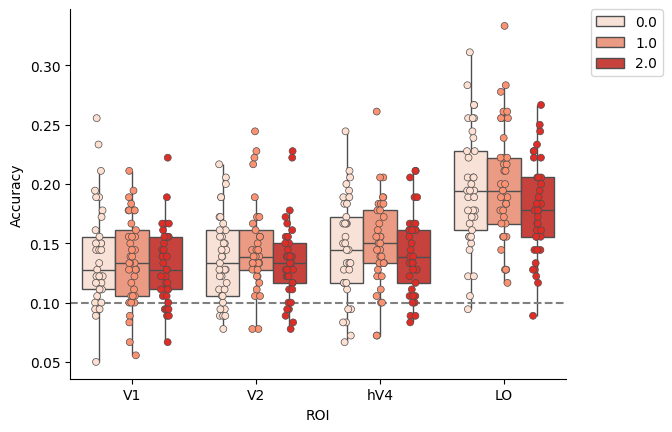

In [33]:
# Box plot

cols = ["#fee0d2", "#fc9272", "#de2d26"]
ax = sns.boxplot(data=all_sub_acc, x="roi", y="mean_acc",
                hue="cond", showcaps=False,
                flierprops={"marker":""},
                palette= cols)  
sns.stripplot(data=all_sub_acc, x="roi", y="mean_acc",
              hue="cond", dodge=True,palette=cols,linewidth=0.5,edgecolor='gray') 
handles, labels = ax.get_legend_handles_labels()
ax.set(xlabel='ROI', ylabel='Accuracy')
ax.legend(handles[0:3], labels[0:3], bbox_to_anchor=(1.05,1), loc=2, borderaxespad=0.)
fig = ax.get_figure()
sns.despine()
ax.axhline(0.1, color='gray', linestyle='--')

In [ ]:
# one sample t-test: vs. chance level

import scipy.stats as stats
from statsmodels.stats.multitest import fdrcorrection

chance_level = 0.1
for roi in rois:
    p_values_roi = []
    for cond in [0.0, 1.0, 2.0]:
        data = np.array([*all_sub_acc['mean_acc'][(all_sub_acc['roi'] == roi) & (all_sub_acc['cond'] == cond)]])
        t_stat, p_value = stats.ttest_1samp(data, chance_level, alternative='greater')
        p_values_roi.append(p_value)

    rejected, corrected_p_values = fdrcorrection(p_values_roi, alpha=0.05)
    print(f'{roi} corrected p-values: {corrected_p_values}')

V1 corrected p-values: [1.33922893e-06 5.69930388e-07 5.69930388e-07]
V2 corrected p-values: [3.09594097e-07 8.64392609e-09 2.19710281e-07]
hV4 corrected p-values: [5.41486240e-08 1.92987798e-09 7.84587464e-09]
LO corrected p-values: [6.17572679e-14 1.89674414e-14 5.58760550e-14]


In [41]:
# pairwise t-test
import pingouin as pg

result = {}
for roi in rois: 
    result[roi] = pg.pairwise_tests(data=all_sub_acc[all_sub_acc["roi"]==roi], dv="mean_acc", between="cond", padjust="fdr_bh")

for roi in rois: 
    print(roi)
    display(result[roi])

V1


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,cond,0.0,1.0,False,True,0.276379,72.0,two-sided,0.783049,0.783049,fdr_bh,0.248,0.063585
1,cond,0.0,2.0,False,True,0.876953,72.0,two-sided,0.383429,0.783049,fdr_bh,0.335,0.201756
2,cond,1.0,2.0,False,True,0.639313,72.0,two-sided,0.524648,0.783049,fdr_bh,0.287,0.147084


V2


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,cond,0.0,1.0,False,True,-1.172027,72.0,two-sided,0.245050,0.367575,fdr_bh,0.434,-0.269642
1,cond,0.0,2.0,False,True,0.297053,72.0,two-sided,0.767282,0.767282,fdr_bh,0.25,0.068341
2,cond,1.0,2.0,False,True,1.526631,72.0,two-sided,0.131234,0.367575,fdr_bh,0.652,0.351224


hV4


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,cond,0.0,1.0,False,True,-0.535069,72.0,two-sided,0.594251,0.635879,fdr_bh,0.272,-0.123101
1,cond,0.0,2.0,False,True,0.475488,72.0,two-sided,0.635879,0.635879,fdr_bh,0.265,0.109393
2,cond,1.0,2.0,False,True,1.096940,72.0,two-sided,0.276323,0.635879,fdr_bh,0.403,0.252367


LO


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,cond,0.0,1.0,False,True,-0.465187,72.0,two-sided,0.643202,0.643202,fdr_bh,0.264,-0.107023
1,cond,0.0,2.0,False,True,1.587069,72.0,two-sided,0.116879,0.175319,fdr_bh,0.706,0.365129
2,cond,1.0,2.0,False,True,2.122707,72.0,two-sided,0.037218,0.111653,fdr_bh,1.626,0.488361


In [ ]:
# ANOVA

import statsmodels.api as sm
from statsmodels.formula.api import ols
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

dat_to_test = all_sub_acc 
model = ols(f'mean_acc~ C(roi) + C(cond)+ C(roi):C(cond)', dat_to_test).fit() 

aov_table = sm.stats.anova_lm(model, typ=2)
aov_table['mean_sq'] = aov_table['sum_sq'] / aov_table['df']
SS_total = aov_table['sum_sq'].sum() + model.ssr
total_row = pd.DataFrame({
'sum_sq': [SS_total],
'df': [aov_table['df'].sum() + model.df_resid],
'mean_sq': [None],
'F': [None],
'PR(>F)': [None]
}, index=['Total'])

# Append the total row to the ANOVA table
anova_complete = pd.concat([aov_table, total_row])
anova_complete

/tmp/ipykernel_878929/184383180.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  anova_complete = pd.concat([aov_table, total_row])


,sum_sq,df,F,PR(>F),mean_sq
C(roi),0.230567,3.0,48.632412,4.258161e-27,0.076856
C(cond),0.011425,2.0,3.614700,2.774254e-02,0.005712
C(roi):C(cond),0.004574,6.0,0.482432,8.215029e-01,0.000762
Residual,0.682706,432.0,NaN,NaN,0.001580
Total,1.611978,875.0,NaN,NaN,NaN


In [38]:
# Post-hoc tukey

from statsmodels.stats.multicomp import pairwise_tukeyhsd

cond_to_str = ['Warmth', 'LowHeat', 'HighHeat']
dat_to_test['Condition'] = dat_to_test.apply(lambda row: cond_to_str[int(row.cond)], axis=1)
comp_var_list = ['roi', 'Condition']
for comp_var in comp_var_list:
    tukey = pairwise_tukeyhsd(dat_to_test['mean_acc'], dat_to_test[comp_var])
    print(comp_var)
    print(tukey)
    print('Exact p-values')
    print(tukey.pvalues)

roi
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    LO     V1  -0.0565    0.0 -0.0703 -0.0427   True
    LO     V2  -0.0531    0.0 -0.0668 -0.0393   True
    LO    hV4  -0.0463    0.0 -0.0601 -0.0326   True
    V1     V2   0.0034 0.9203 -0.0104  0.0172  False
    V1    hV4   0.0101 0.2338 -0.0037  0.0239  False
    V2    hV4   0.0067 0.5929 -0.0071  0.0205  False
----------------------------------------------------
Exact p-values
[2.68340905e-13 2.68340905e-13 2.68896017e-13 9.20256165e-01
 2.33758101e-01 5.92893446e-01]
Condition
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2 meandiff p-adj   lower  upper  reject
------------------------------------------------------
HighHeat LowHeat   0.0123 0.0548 -0.0002 0.0247  False
HighHeat  Warmth   0.0078 0.3053 -0.0047 0.0203  False
 LowHeat  Warmth  -0.0045 0.6769 -0.0169  0.008  False
------------------